In [17]:
import joblib

# Load each model I saved earlier
model_dt = joblib.load('decision_tree_model.pkl')
model_rf = joblib.load('random_forest_model.pkl')
model_xgb = joblib.load('XGBoost_Model.pkl')


In [2]:

print("XGBoost features:", model_xgb.feature_names_in_)
print("RF features:", model_rf.feature_names_in_)
print("DT features:", model_dt.feature_names_in_)


XGBoost features: ['const' 'residence' 'hv270' 'improved_toilet' 'handwashing_water']
RF features: ['residence' 'hv270' 'hv216' 'hv271' 'hv205_flush to septic tank'
 'hv205_flush to pit latrine' 'hv205_flush to somewhere else'
 "hv205_flush, don't know where"
 'hv205_ventilated improved pit latrine (vip)'
 'hv205_pit latrine with slab' 'hv205_pit latrine without slab/open pit'
 'hv205_no facility/bush/field' 'hv205_composting toilet'
 'hv205_bucket toilet' 'hv205_hanging toilet/latrine' 'hv205_other'
 'hv225_yes' 'hv219_female' 'hv220_16' 'hv220_17' 'hv220_18' 'hv220_19'
 'hv220_20' 'hv220_21' 'hv220_22' 'hv220_23' 'hv220_24' 'hv220_25'
 'hv220_26' 'hv220_27' 'hv220_28' 'hv220_29' 'hv220_30' 'hv220_31'
 'hv220_32' 'hv220_33' 'hv220_34' 'hv220_35' 'hv220_36' 'hv220_37'
 'hv220_38' 'hv220_39' 'hv220_40' 'hv220_41' 'hv220_42' 'hv220_43'
 'hv220_44' 'hv220_45' 'hv220_46' 'hv220_47' 'hv220_48' 'hv220_49'
 'hv220_50' 'hv220_51' 'hv220_52' 'hv220_53' 'hv220_54' 'hv220_55'
 'hv220_56' 'hv220_5

In [3]:
import os
folder = r'C:\Users\USER\Desktop\ISID_DHS_PROJECT\data\NGHR8BDT'
print("Folder exists:", os.path.exists(folder))
print("Files inside:", os.listdir(folder))



Folder exists: True
Files inside: ['NGHR8BFL.DCT', 'NGHR8BFL.DO', 'NGHR8BFL.dta', 'NGHR8BFL.frq', 'NGHR8BFL.frw', 'NGHR8BFL.map']


In [4]:
import pandas as pd
import joblib
import numpy as np

model_dt = joblib.load('decision_tree_model.pkl')
model_rf = joblib.load('random_forest_model.pkl')
model_xgb = joblib.load('XGBoost_Model.pkl')

# USE NGHR8BFL.dta - this IS the household file
df = pd.read_stata(r'C:\Users\USER\Desktop\ISID_DHS_PROJECT\data\NGHR8BDT\NGHR8BFL.dta')

df = df.rename(columns={'hv024': 'state'})
df['const'] = 1

print("Loaded! Shape:", df.shape)
print("Columns sample:", df.columns[:10])

Loaded! Shape: (40047, 3982)
Columns sample: Index(['hhid', 'hv000', 'hv001', 'hv002', 'hv003', 'hv004', 'hv005', 'hv006',
       'hv007', 'hv008'],
      dtype='object')


In [5]:
print(df.columns.tolist()[:30]) # first 30 columns

['hhid', 'hv000', 'hv001', 'hv002', 'hv003', 'hv004', 'hv005', 'hv006', 'hv007', 'hv008', 'hv008a', 'hv009', 'hv010', 'hv011', 'hv012', 'hv013', 'hv014', 'hv015', 'hv016', 'hv017', 'hv018', 'hv019', 'hv020', 'hv021', 'hv022', 'hv023', 'state', 'hv025', 'hv026', 'hv027']


In [6]:
import pandas as pd
import numpy as np

# ===== 1. DT + RF PREDICTIONS =====
cat_cols_dt = ['hv024', 'hv205', 'hv025', 'hv219', 'hv220', 'hv225', 'hv230a', 'hv230b']
num_cols_dt = ['hv270', 'hv216', 'hv009', 'hv014', 'hv026', 'hv271']

cat_cols_dt = [c for c in cat_cols_dt if c in df.columns]
num_cols_dt = [c for c in num_cols_dt if c in df.columns]

X_dt = df[cat_cols_dt + num_cols_dt].copy()
for col in num_cols_dt:
    X_dt[col] = pd.to_numeric(X_dt[col], errors='coerce')
X_dt[num_cols_dt] = X_dt[num_cols_dt].fillna(X_dt[num_cols_dt].median(numeric_only=True))
X_dt = pd.get_dummies(X_dt, columns=cat_cols_dt, drop_first=False)

expected_dt = model_dt.feature_names_in_
for col in expected_dt:
    if col not in X_dt.columns: X_dt[col] = 0
X_dt = X_dt[expected_dt]

df['risk_dt'] = model_dt.predict_proba(X_dt)[:, 1]
df['risk_rf'] = model_rf.predict_proba(X_dt)[:, 1]

# ===== 2. XGB PREDICTIONS =====
X_xgb = pd.DataFrame()
X_xgb['const'] = 1
X_xgb['residence'] = pd.to_numeric(df['hv025'], errors='coerce') # force to number
X_xgb['hv270'] = pd.to_numeric(df['hv270'], errors='coerce')

# Engineered features - adjust codes if needed for NDHS 2018
X_xgb['improved_toilet'] = df['hv205'].isin([11,12,13,21,22]).astype(int)
X_xgb['handwashing_water'] = (df['hv230b'] == 1).astype(int)

# SAFE FILLNA: only numeric columns
X_xgb = X_xgb.fillna(X_xgb.median(numeric_only=True))

expected_xgb = model_xgb.feature_names_in_
X_xgb = X_xgb[expected_xgb]

df['risk_xgb'] = model_xgb.predict_proba(X_xgb)[:, 1]

# ===== 3. AVERAGE + STATE TABLE =====
df['risk_avg'] = df[['risk_dt', 'risk_rf', 'risk_xgb']].mean(axis=1)

state_map = {
    1: 'Abia', 2: 'Adamawa', 3: 'Akwa Ibom', 4: 'Anambra', 5: 'Bauchi',
    6: 'Bayelsa', 7: 'Benue', 8: 'Borno', 9: 'Cross River', 10: 'Delta',
    11: 'Ebonyi', 12: 'Edo', 13: 'Ekiti', 14: 'Enugu', 15: 'Gombe',
    16: 'Imo', 17: 'Jigawa', 18: 'Kaduna', 19: 'Kano', 20: 'Katsina',
    21: 'Kebbi', 22: 'Kogi', 23: 'Kwara', 24: 'Lagos', 25: 'Nasarawa',
    26: 'Niger', 27: 'Ogun', 28: 'Ondo', 29: 'Osun', 30: 'Oyo',
    31: 'Plateau', 32: 'Rivers', 33: 'Sokoto', 34: 'Taraba', 35: 'Yobe', 36: 'Zamfara', 37: 'FCT'
}
df['state_name'] = df['state'].map(state_map)

state_risk = df.groupby('state_name')['risk_avg'].mean().sort_values(ascending=False).reset_index()
state_risk.columns = ['State', 'Average_Risk']

print("\n=== STATE LEVEL AVERAGE DIARRHEA RISK ===")
print(state_risk)


=== STATE LEVEL AVERAGE DIARRHEA RISK ===
Empty DataFrame
Columns: [State, Average_Risk]
Index: []


In [7]:
print(df['state'].value_counts().head(20))
print(df['state'].dtype)

state
north central    7615
north west       7591
south west       7173
south south      6394
north east       5977
south east       5297
Name: count, dtype: int64
category


In [8]:
import pandas as pd
import numpy as np



# 1. CLEAN THE ZONE NAMES
df['zone'] = df['state'].str.title() # Capitalize: North Central etc

# 2. AGGREGATE BY ZONE
zone_risk = df.groupby('zone')['risk_avg'].agg(['mean', 'count']).reset_index()
zone_risk.columns = ['Zone', 'Average_Risk', 'N_Households']
zone_risk = zone_risk.sort_values('Average_Risk', ascending=False)

print("\n=== ZONAL LEVEL AVERAGE DIARRHEA RISK ===")
print(zone_risk.round(4))


=== ZONAL LEVEL AVERAGE DIARRHEA RISK ===
            Zone  Average_Risk  N_Households
5     South West        0.9099          7173
4    South South        0.8801          6394
3     South East        0.8708          5297
0  North Central        0.8025          7615
2     North West        0.7379          7591
1     North East        0.7200          5977


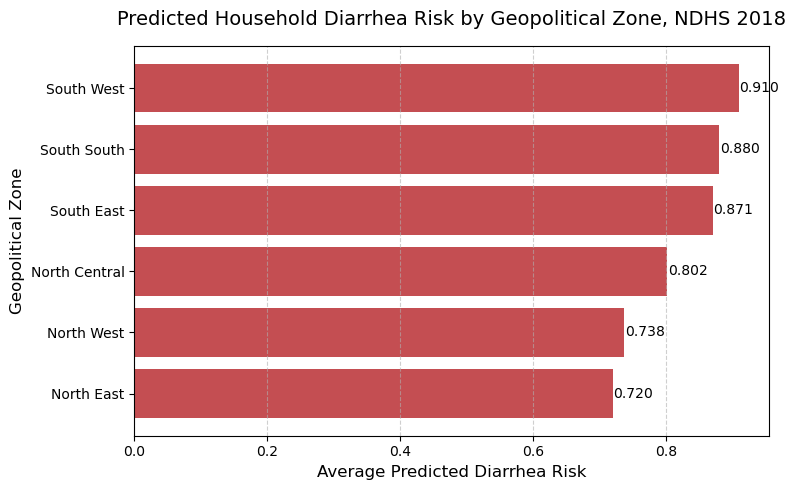

In [9]:
import matplotlib.pyplot as plt
import pandas as pd


zone_risk = zone_risk.sort_values('Average_Risk')

plt.figure(figsize=(8, 5))
bars = plt.barh(zone_risk['Zone'], zone_risk['Average_Risk'], color='#c44e52')

plt.xlabel('Average Predicted Diarrhea Risk', fontsize=12)
plt.ylabel('Geopolitical Zone', fontsize=12)
plt.title('Predicted Household Diarrhea Risk by Geopolitical Zone, NDHS 2018', fontsize=14, pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add values on bars
for bar in bars:
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("nigeria_diarrhea_risk_bar.png", dpi=300)
plt.show()

In [10]:
import geopandas as gpd

gdf = gpd.read_file(r"C:\Users\USER\Downloads\nga_admin_boundaries.shp\nga_admin1.shp")
print(gdf.columns)
print(gdf.head())

Index(['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',
       'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry'],
      dtype='object')
   adm1_name adm1_name1 adm1_name2 adm1_name3 adm1_pcode adm0_name adm0_name1  \
0       Abia       None       None       None      NG001   Nigeria       None   
1    Adamawa       None       None       None      NG002   Nigeria       None   
2  Akwa Ibom       None       None       None      NG003   Nigeria       None   
3    Anambra       None       None       None      NG004   Nigeria       None   
4     Bauchi       None       None       None      NG005   Nigeria       None   

  adm0_name2 adm0_name3 adm0_pcode  ...     area_sqkm version  lang lang1  \
0       None       None         NG  ...   4859.503138     v01    en  None   
1       None       None         N

            Zone  Average_Risk
0  North Central      0.802480
1     North East      0.719992
2     North West      0.737883
3     South East      0.870755
4    South South      0.880134
5     South West      0.909910


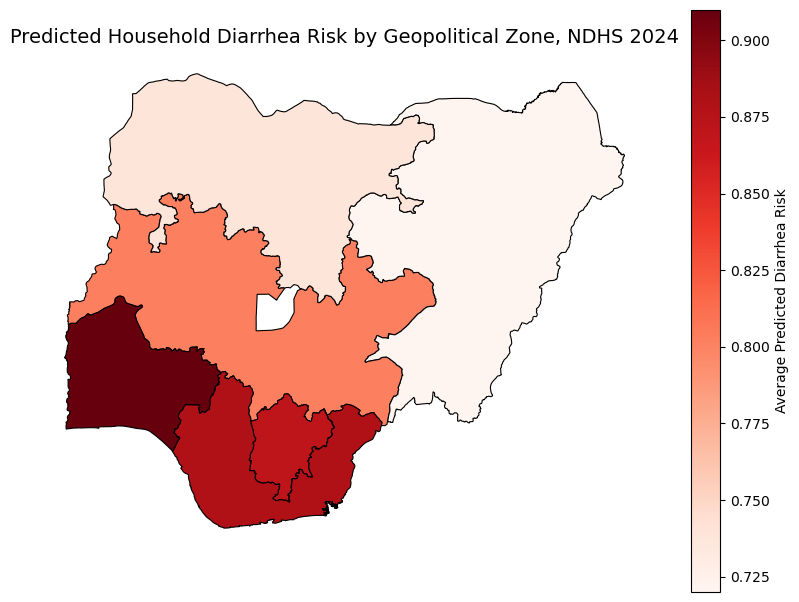

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Level 1 = All 36 states
gdf = gpd.read_file(r"C:\Users\USER\Downloads\nga_admin_boundaries.shp\nga_admin1.shp")

# 2. Create a dictionary to map states to zones
zone_map = {
    'North Central': ['Benue', 'Kogi', 'Kwara', 'Nasarawa', 'Niger', 'Plateau'],
    'North East': ['Adamawa', 'Bauchi', 'Borno', 'Gombe', 'Taraba', 'Yobe'],
    'North West': ['Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Sokoto', 'Zamfara'],
    'South East': ['Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo'],
    'South South': ['Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers'],
    'South West': ['Ekiti', 'Lagos', 'Ogun', 'Ondo', 'Osun', 'Oyo']
}

# 3. Assign each state to a zone
def get_zone(state):
    for zone, states in zone_map.items():
        if state in states:
            return zone
    return None

gdf['Zone'] = gdf['adm1_name'].apply(get_zone)

# 4. Dissolve states into zones and merge with your risk data
gdf_zones = gdf.dissolve(by='Zone').reset_index()
gdf_zones = gdf_zones.merge(zone_risk, on='Zone', how='left')

print(gdf_zones[['Zone', 'Average_Risk']]) # Check it worked

# 5. PLOT
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gdf_zones.plot(column='Average_Risk', 
         cmap='Reds', 
         linewidth=0.8, 
         ax=ax, 
         edgecolor='black',
         legend=True,
         legend_kwds={'label': "Average Predicted Diarrhea Risk", 'shrink': 0.6})

ax.set_title('Predicted Household Diarrhea Risk by Geopolitical Zone, NDHS 2024', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig("nigeria_diarrhea_risk_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import os
print(os.getcwd())

C:\Users\USER


            Zone  Average_Risk
0  North Central      0.802480
1     North East      0.719992
2     North West      0.737883
3     South East      0.870755
4    South South      0.880134
5     South West      0.909910
✅ Map saved to: C:\Users\USER\Desktop\nigeria_diarrhea_risk_map_2024.png


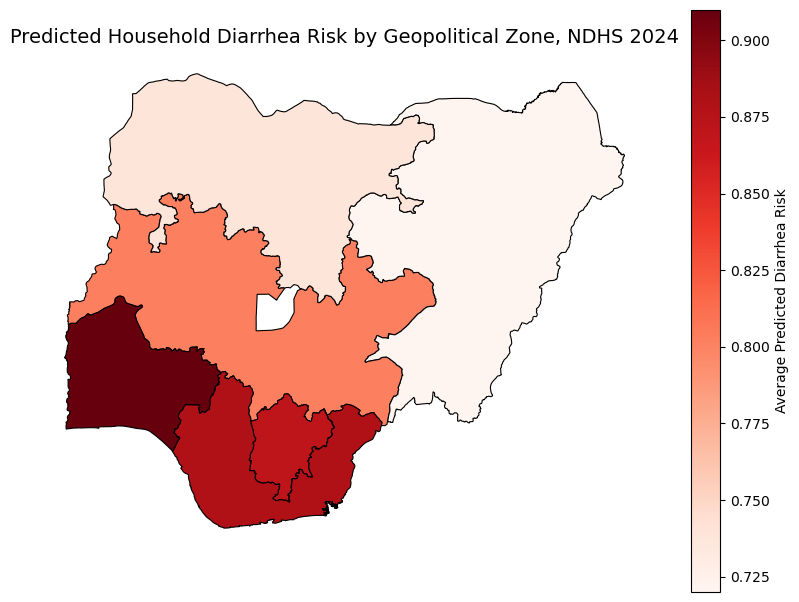

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os  # <- added

# 1. Load Level 1 = All 36 states
gdf = gpd.read_file(r"C:\Users\USER\Downloads\nga_admin_boundaries.shp\nga_admin1.shp")

# 2. Create a dictionary to map states to zones
zone_map = {
    'North Central': ['Benue', 'Kogi', 'Kwara', 'Nasarawa', 'Niger', 'Plateau', 'FCT'], # added FCT
    'North East': ['Adamawa', 'Bauchi', 'Borno', 'Gombe', 'Taraba', 'Yobe'],
    'North West': ['Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Sokoto', 'Zamfara'],
    'South East': ['Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo'],
    'South South': ['Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers'],
    'South West': ['Ekiti', 'Lagos', 'Ogun', 'Ondo', 'Osun', 'Oyo']
}

# 3. Assign each state to a zone
def get_zone(state):
    for zone, states in zone_map.items():
        if state in states:
            return zone
    return None

gdf['Zone'] = gdf['adm1_name'].apply(get_zone)

# 4. Dissolve states into zones and merge with your risk data
gdf_zones = gdf.dissolve(by='Zone').reset_index()
gdf_zones = gdf_zones.merge(zone_risk, on='Zone', how='left')

print(gdf_zones[['Zone', 'Average_Risk']]) # Check it worked

# 5. PLOT
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gdf_zones.plot(column='Average_Risk', 
         cmap='Reds', 
         linewidth=0.8, 
         ax=ax, 
         edgecolor='black',
         legend=True,
         legend_kwds={'label': "Average Predicted Diarrhea Risk", 'shrink': 0.6})

ax.set_title('Predicted Household Diarrhea Risk by Geopolitical Zone, NDHS 2024', fontsize=14)
ax.axis('off')
plt.tight_layout()


desktop = os.path.join(os.path.expanduser("~"), "Desktop") 
save_path = os.path.join(desktop, "nigeria_diarrhea_risk_map_2024.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight') # save to Desktop
print(f"✅ Map saved to: {save_path}")
# ------------------------------------------

plt.show()


=== TABLE OF ZONE VS AVERAGE RISK ===
         Zone  Average_Risk
   South West      0.909910
  South South      0.880134
   South East      0.870755
North Central      0.802480
   North West      0.737883
   North East      0.719992

✅ Table saved to: C:\Users\USER\Desktop\zone_risk_table_2024.csv
✅ Map saved to: C:\Users\USER\Desktop\nigeria_diarrhea_risk_map_2024.png


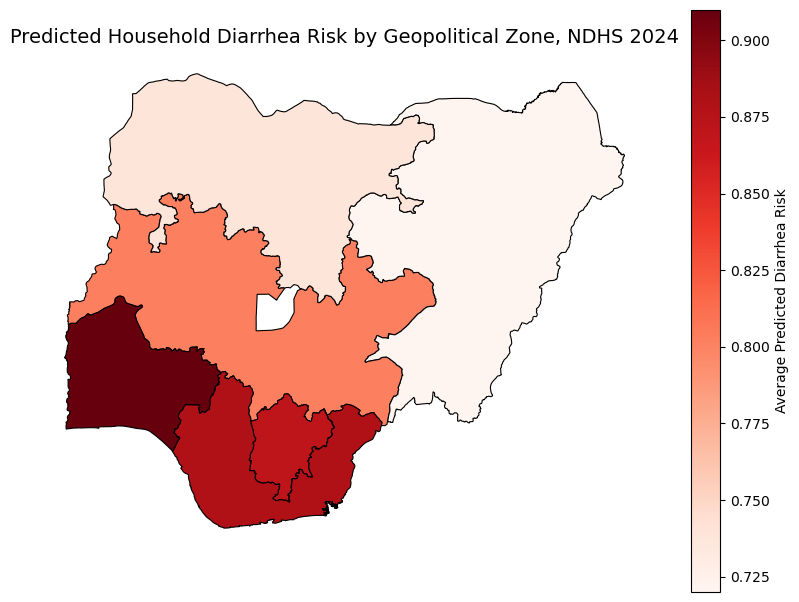

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Load Level 1 = All 36 states
gdf = gpd.read_file(r"C:\Users\USER\Downloads\nga_admin_boundaries.shp\nga_admin1.shp")

# 2. Map states to 6 geopolitical zones
zone_map = {
    'North Central': ['Benue', 'Kogi', 'Kwara', 'Nasarawa', 'Niger', 'Plateau', 'FCT'],
    'North East': ['Adamawa', 'Bauchi', 'Borno', 'Gombe', 'Taraba', 'Yobe'],
    'North West': ['Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Sokoto', 'Zamfara'],
    'South East': ['Abia', 'Anambra', 'Ebonyi', 'Enugu', 'Imo'],
    'South South': ['Akwa Ibom', 'Bayelsa', 'Cross River', 'Delta', 'Edo', 'Rivers'],
    'South West': ['Ekiti', 'Lagos', 'Ogun', 'Ondo', 'Osun', 'Oyo']
}

def get_zone(state):
    for zone, states in zone_map.items():
        if state in states:
            return zone
    return None

gdf['Zone'] = gdf['adm1_name'].apply(get_zone)

# 3. Group states into zones and merge with your risk data
gdf_zones = gdf.dissolve(by='Zone').reset_index()
gdf_zones = gdf_zones.merge(zone_risk, on='Zone', how='left')

# 4. CREATE AND SAVE THE TABLE
table = gdf_zones[['Zone', 'Average_Risk']].sort_values('Average_Risk', ascending=False)
print("\n=== TABLE OF ZONE VS AVERAGE RISK ===")
print(table.to_string(index=False)) # prints nicely

# Save table to Desktop
desktop = os.path.join(os.path.expanduser("~"), "Desktop")
table_path = os.path.join(desktop, "zone_risk_table_2024.csv")
table.to_csv(table_path, index=False)
print(f"\n✅ Table saved to: {table_path}")

# 5. PLOT MAP
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gdf_zones.plot(column='Average_Risk', 
         cmap='Reds', 
         linewidth=0.8, 
         ax=ax, 
         edgecolor='black',
         legend=True,
         legend_kwds={'label': "Average Predicted Diarrhea Risk", 'shrink': 0.6})

ax.set_title('Predicted Household Diarrhea Risk by Geopolitical Zone, NDHS 2024', fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save map to Desktop
save_path = os.path.join(desktop, "nigeria_diarrhea_risk_map_2024.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Map saved to: {save_path}")

plt.show()

✅ Map saved to: C:\Users\USER\Desktop\nigeria_diarrhea_risk_map_2024.png


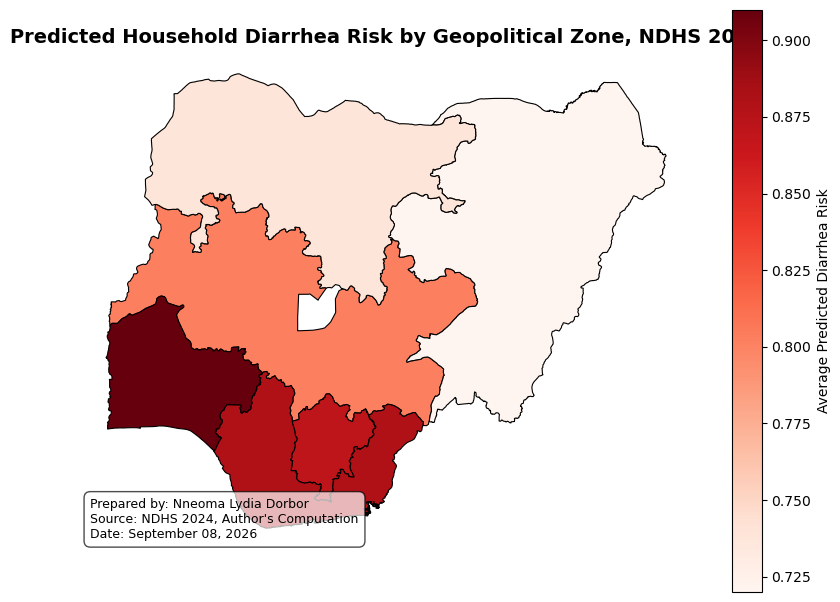

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import date # to add today's date


# 5. PLOT MAP WITH LABELS
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gdf_zones.plot(column='Average_Risk', 
         cmap='Reds', 
         linewidth=0.8, 
         ax=ax, 
         edgecolor='black',
         legend=True,
         legend_kwds={'label': "Average Predicted Diarrhea Risk", 'shrink': 0.6})

ax.set_title('Predicted Household Diarrhea Risk by Geopolitical Zone, NDHS 2024', fontsize=14, fontweight='bold')
ax.axis('off')


my_name = "Prepared by: Nneoma Lydia Dorbor" 
data_source = "Source: NDHS 2024, Author's Computation"
today = f"Date: {date.today().strftime('%B %d, %Y')}"

# Position: x=0.02 left, y=0.02 bottom. transform=ax.transAxes uses 0-1 scale
ax.text(0.02, 0.02, f"{my_name}\n{data_source}\n{today}", 
        transform=ax.transAxes, fontsize=9, 
        verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

plt.tight_layout()

# Save map to Desktop
desktop = os.path.join(os.path.expanduser("~"), "Desktop")
save_path = os.path.join(desktop, "nigeria_diarrhea_risk_map_2024.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Map saved to: {save_path}")

plt.show()

✅ Map saved to: C:\Users\USER\Desktop\nigeria_diarrhea_risk_map_2024.png


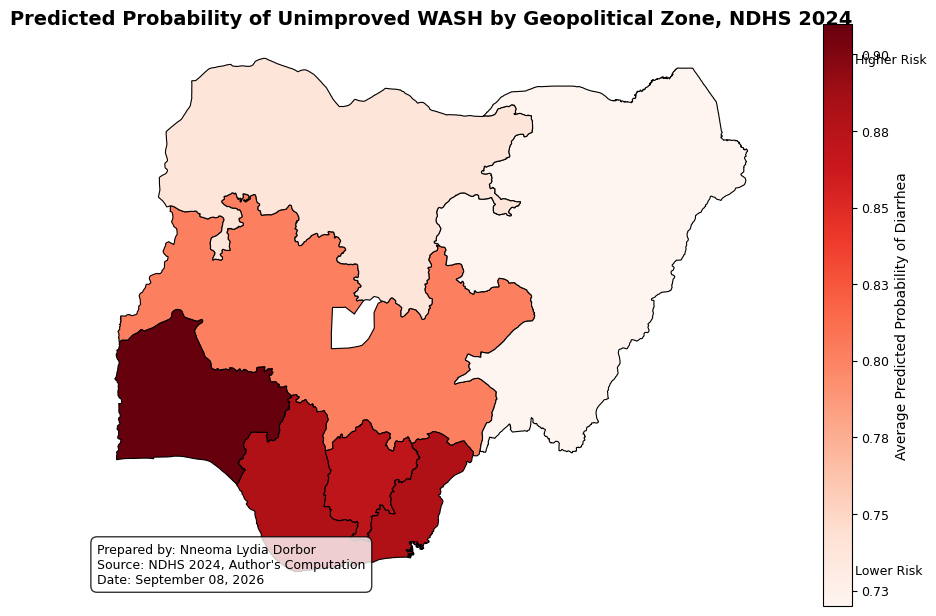

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import date


# 5. PLOT MAP WITH BETTER LEGEND
fig, ax = plt.subplots(1, 1, figsize=(9, 10))
gdf_zones.plot(column='Average_Risk',
         cmap='Reds',
         linewidth=0.8,
         ax=ax,
         edgecolor='black',
         legend=True,
         legend_kwds={
             'label': "Average Predicted Probability of Diarrhea", # <- Legend title
             'orientation': "vertical",
             'shrink': 0.6
             # REMOVED 'format' because it causes the error
         })

ax.set_title('Predicted Probability of Unimproved WASH by Geopolitical Zone, NDHS 2024', fontsize=14, fontweight='bold')
ax.axis('off')

# Get the colorbar and format the ticks manually
cbar = ax.get_figure().axes[1] # colorbar is the 2nd axis
cbar.tick_params(labelsize=9)
# Force 2 decimal places
import matplotlib.ticker as ticker
cbar.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Add Higher/Lower Risk labels
cbar.text(1.1, 0.95, 'Higher Risk', transform=cbar.transAxes, fontsize=9, va='top')
cbar.text(1.1, 0.05, 'Lower Risk', transform=cbar.transAxes, fontsize=9, va='bottom')

# ADD FOOTER
my_name = "Prepared by: Nneoma Lydia Dorbor" # <- CHANGE THIS
data_source = "Source: NDHS 2024, Author's Computation"
today = f"Date: {date.today().strftime('%B %d, %Y')}"
ax.text(0.02, 0.02, f"{my_name}\n{data_source}\n{today}",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

plt.tight_layout()

# Save
desktop = os.path.join(os.path.expanduser("~"), "Desktop")
save_path = os.path.join(desktop, "nigeria_diarrhea_risk_map_2024.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Map saved to: {save_path}")

plt.show()